# Selenium이란?
* 웹브라우저를 자동으로 제어하는 라이브러리
* 원래 다양한 웹브라우저를 자동으로 테스트하는 도구
* 코드를 통해 웹브라우저 조작 가능
* 동적 웹사이트에서 정보를 가져오는데 활용

* options 관련 링크
https://www.selenium.dev/documentation/webdriver/browsers/chrome/

In [2]:
# !pip install selenium
# !pip install webdriver-manager

In [3]:
import selenium
print(selenium.__version__)

4.37.0


In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")


driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
driver.get("https://search.shopping.naver.com/book/search?bookTabType=ALL&pageIndex=1&pageSize=40&prevQuery=%EB%84%A4%EC%9D%B4%EB%B2%84%20%EC%B1%85&query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&sort=REL")

# selenium에서 원하는 요소찾기

https://www.selenium.dev/documentation/webdriver/elements/finders/

* driver.find_element(By.CSS_SELECTOR, css셀렉터): 1개의 요소 찾기
* driver.find_elements(By.CSS_SELECTOR, css셀렉터): 여러개의 요소 찾기, list반환
* driver.find_element(By.ID, "id"): html에서 id 속성을 찾아줌
* driver.find_element(By.LINK_TEXT, "link에 포함된 문자"): link에 포함된 문자 찾기
* driver.find_element(By.PARTIAL_LINK_TEXT, "link에 포함된 일부 문자"): link에 포함된 문자 찾기


In [5]:
driver.find_element(By.CSS_SELECTOR, "div.bookListItem_title__1mWGq").text

'모의 침투 입문자를 위한 파이썬 3 활용 (파이썬 3 기반의 TCP/IP 활용 지침서)'

In [6]:
driver.find_element(By.ID, "book_list").find_element(By.CSS_SELECTOR, "a").get_attribute("href")

'https://search.shopping.naver.com/book/search?bookTabType=ALL&pageIndex=1&pageSize=40&prevQuery=%EB%84%A4%EC%9D%B4%EB%B2%84%20%EC%B1%85&query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&sort=REL#'

In [7]:
driver.find_element(By.PARTIAL_LINK_TEXT, "점프").get_attribute("innerHTML")

'<div class="bookListItem_thumbnail_area__W3MCC"><div class="bookListItem_thumbnail__ABXyE"><img src="https://shopping-phinf.pstatic.net/main_4035408/40354085633.20230927071024.jpg?type=w300" alt="Do it! 점프 투 파이썬"></div></div><div class="bookListItem_text_area__6gSV2"><div class="bookListItem_feature__Tck1v">컴퓨터/IT 10위</div><div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>Do it! 점프 투 파이썬</span><span> (중학생도 첫날부터 실습하는 초고속 입문서)</span></span></div><div class="bookListItem_detail__VW1kD"><div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">박응용</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">이지스퍼블리싱</span></div><div class="bookListItem_detail_date__6_wYJ">2023.06.15.</div></div></d

In [8]:
driver.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text

'평점4.96 (83)'

# 찾은 요소에서 요소의 속성값 출력하기
* find_element(By.CSS_SELECTOR, "css셀렉터").get_attribute("속성명")

In [9]:
seller_link = "#book_list > ul > li:nth-child(1) > div > div > div:nth-child(1) > a"

In [10]:
driver.find_element(By.CSS_SELECTOR, seller_link).get_attribute("data-shp-page-key")

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"css selector","selector":"#book_list > ul > li:nth-child(1) > div > div > div:nth-child(1) > a"}
  (Session info: chrome=141.0.7390.108); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
	GetHandleVerifier [0x0xdafe43+66515]
	GetHandleVerifier [0x0xdafe84+66580]
	(No symbol) [0x0xb9dc48]
	(No symbol) [0x0xbe8704]
	(No symbol) [0x0xbe8aab]
	(No symbol) [0x0xc2f482]
	(No symbol) [0x0xc0b214]
	(No symbol) [0x0xc2cba7]
	(No symbol) [0x0xc0afc6]
	(No symbol) [0x0xbdc2ca]
	(No symbol) [0x0xbdd154]
	GetHandleVerifier [0x0x1007353+2521315]
	GetHandleVerifier [0x0x10022d3+2500707]
	GetHandleVerifier [0x0xdd7c94+229924]
	GetHandleVerifier [0x0xdc81f8+165768]
	GetHandleVerifier [0x0xdcecad+193085]
	GetHandleVerifier [0x0xdb8158+100072]
	GetHandleVerifier [0x0xdb82f0+100480]
	GetHandleVerifier [0x0xda25aa+110

In [11]:
import time
y = 0
y_step = 1000
for scroll_times in range(1, 8):
    y = y + y_step
    driver.execute_script(f"window.scrollTo({0}, {y})")
    time.sleep(2)

In [12]:
driver.find_element(By.CSS_SELECTOR, "div.bookListItem_title__1mWGq").text

'모의 침투 입문자를 위한 파이썬 3 활용 (파이썬 3 기반의 TCP/IP 활용 지침서)'

In [13]:
driver.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")

'https://search.shopping.naver.com/book/search?bookTabType=ALL&pageIndex=1&pageSize=40&prevQuery=%EB%84%A4%EC%9D%B4%EB%B2%84%20%EC%B1%85&query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&sort=REL#'

In [14]:
driver.find_element(By.PARTIAL_LINK_TEXT, "파이썬").get_attribute('innerHTML')

'<span class="blind">모의 침투 입문자를 위한 파이썬 3 활용</span>'

# 검색창을 찾아 검색어 입력하고 서치버튼 클릭하기

https://www.selenium.dev/documentation/webdriver/elements/interactions/

* 키보드 입력하기
  * driver.send_keys("핀테크").send_keys(Keys.ENTER)
* 마우스 클릭하기
  * driver.click()

In [15]:
driver.find_element(By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click").get_attribute('outerHTML')

'<input type="text" class="_searchInput_search_text_83jy9 _nlog_click" title="검색어 입력" placeholder="도서명 또는 저자명 입력" maxlength="50" data-shp-page-key="100388780" data-shp-nsc="shopping.book" data-shp-inventory="GNB" data-shp-area="GNB.input" data-shp-area-type="action" data-shp-area-id="input" value="파이썬">'

In [16]:
serch_box = driver.find_element(By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click")
serch_box.clear()
serch_box.send_keys("파이썬")
serch_box.send_keys(Keys.ENTER)

search_button = driver.find_element(By.CSS_SELECTOR, "._searchInput_button_search_wu9xq._nlog_click")
search_button.click()

'<html lang="ko"><head><meta charset="utf-8" data-next-head=""><meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no, minimum-scale=1.0, maximum-scale=1.0, user-scalable=no, viewport-fit=cover" data-next-head=""><meta http-equiv="Cache-Control" content="no-cache, no-store, must-revalidate" data-next-head=""><title data-next-head="">파이썬 : 네이버 도서</title><link rel="shortcut icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-251001-110341/img/favicon.ico" data-next-head=""><link rel="apple-touch-icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-251001-110341/img/favicon_180.png" data-next-head=""><meta property="og:title" content="파이썬 : 네이버 도서" data-next-head=""><meta property="og:description" content="\'파이썬\'의 네이버 도서 검색 결과입니다." data-next-head=""><meta property="og:image" content="https://ssl.pstatic.net/shoppingsearch/static/icons/ogtag_shopping_book.png" data-next-head=""><meta property="og:url" content="https://search.sho
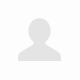
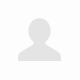

In [17]:
html_source = driver.page_source
html_source

In [18]:
from bs4 import BeautifulSoup as bs
soup = bs(html_source, 'lxml')
soup.select("div.bookListItem_title__1mWGq")

[<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>Do it! 점프 투 파이썬</span><span> (중학생도 첫날부터 실습하는 초고속 입문서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>으뜸 파이썬</span><span> (개정판)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>독학 파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (제2판)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (비전공자를위한 파이썬 기초 입문서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span>

# 웹페이지가 모두 로딩 될 때 까지 기다리기
* from selenium.webdrive.support.ui import WebDriverWait
* from selenium.webdrive.support import expected_conditions as EC

*EC.element_to_be_clicable
*EC.presence_of_element_located



```python
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clicable(By.ID, "submit-button"))
button.click()
```

In [21]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable(
    (By.CSS_SELECTOR, "button._searchInput_button_search_wu9xq._nlog_click")
))
button.click()

네이버 가격비교 도서에서 파이썬 책 찾아서 5페이지 정보 데이터 프레임으로 만들기

In [22]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)


In [23]:
# 페이지 시작부터 끝까지 스크롤하기
import time
for scroll in range(0, 8001, 1000):
    driver.execute_script(f"window.scrollTo({0}, {scroll})")
    time.sleep(2)
                          
    

In [24]:
# 책 목록 전체 가져오기 find_elements
book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

In [25]:
# 책 제목  bookListItem_title__1mWGq
title = driver.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
#세부링크 bookListItem_item_inner__edK7P
detail_link = driver.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
# 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
author = driver.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
# 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
publisher = driver.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
# 출간일 .bookListItem_detail_date__6_wYJ
pub_date = driver.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
# 평점 .bookListItem_grade__e60mi
grade = float(driver.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
# 가격 .bookPrice_price__Nv4Ee > em
price = int(driver.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))

print(title, detail_link, author, publisher, pub_date, grade, price)

파이썬을 활용한 무역데이터분석 https://search.shopping.naver.com/book/search?bookTabType=ALL&pageIndex=1&pageSize=40&query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&sort=REL# 민인식,최필선 지필미디어 2025.05.30. 4.9 24300


In [26]:
# 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
paginator.find_element(By.LINK_TEXT, "3").click()

# 코드 합쳐서 5페이지 정보 모두 수집하기

In [27]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(2)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for book in book_list:
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        #세부링크 bookListItem_item_inner__edK7P
        detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
        author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
        publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        # 출간일 .bookListItem_detail_date__6_wYJ
        pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()

OSError: Cannot save file into a non-existent directory: 'scraping_results'

# 검색어를 입력받아 Naver 도서에서 검색하고 검색결과를 DB 모듈을 이용해 DB에 저장하기

In [17]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd
from book_dbio import to_book_db
from translate import kor2eng


keyword = input("검색할 책을 입력해 주세요. ")
eng_keyword = kor2eng(keyword)

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")
# options.add_argument("--headless")  
# options.add_argument("--no-sandbox")
# options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )


url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys(keyword)
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    print(f"{num} / {len(range(1,6))} 페이지 작업중", end="\n")
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(0.5)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for idx, book in enumerate(book_list):
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        
        try:
            #세부링크 bookListItem_item_inner__edK7P
            detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        except Exception:
            detail_link = "Unknown"
        try:
            # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
            author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        except Exception:
            author = "Unknown"
        try:
            # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
            publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        except Exception:
            publisher = "Unknown"
        try:
            # 출간일 .bookListItem_detail_date__6_wYJ
            pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        except Exception:
            pub_date = "Unknown"
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        to_book_db(eng_keyword, result)
#         result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        print(f"                                                       {idx+1}/{len(book_list)} DB 저장완료", end="\r")
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()

검색할 책을 입력해 주세요. 머신러닝
1 / 5 페이지 작업중


C:\fintech\04data_scraping\book_dbio.py:21: UserWarning: The provided table name 'Machine learning_book_info' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  df.to_sql(f'{keyword}_book_info', con=conn,  if_exists="append", index=False)


2 / 5 페이지 작업중                                          40/40 DB 저장완료
3 / 5 페이지 작업중                                          40/40 DB 저장완료
4 / 5 페이지 작업중                                          40/40 DB 저장완료
5 / 5 페이지 작업중                                          40/40 DB 저장완료
